In [102]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
%matplotlib inline

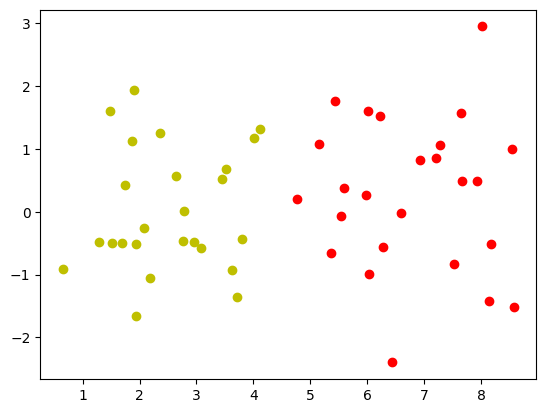

In [103]:
#Q1: part 1
#generating a 2D dataset
n=50
X, y = datasets.make_blobs(n_samples=n, centers=2, n_features=2, center_box=(0, 10), cluster_std=1, random_state=41)

#visualizing dataset
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'yo')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'ro')
plt.show()

#splitting data
y = y*2-1
y = y.reshape(n,1)

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.4,random_state=420)

In [104]:
#Q1: part 2: Batch Preceptron
class Perceptron(object):
  def __init__(self, X_train, Y_train, lr, epochs=100, epsilon=1e-5):
    # add one for bias
    self.n, _ = X_train.shape
    self.X_train = np.c_[np.ones(self.n), X_train]
    _, self.d = self.X_train.shape
    # self.W = [[0.1],[0.1],[0]]
    self.W = np.zeros([self.d, 1])
    self.epochs, self.lr, self.epsilon = epochs, lr, epsilon
    self.y_true = Y_train

  def activation_fn(self, x):
    return 2*(x>0)-1

  def predict(self, x):
    z = x.dot(self.W)
    a = self.activation_fn(z)
    return a

  def seq_fit(self, verbose=False, plot=False):
    """
    Sequential Perceptron algorithm.
    """
    error_list = []
    for epoch in range(self.epochs):
      if np.all([np.squeeze(self.predict(self.X_train)) == np.squeeze(self.y_true)]):
        break
      for i in range(self.n):
        y_pred = self.predict(self.X_train[i])
        if y_pred != self.y_true[i]:
          self.W = self.W + self.lr*(self.y_true[i] * self.X_train[i].reshape([self.d,1]))
      err = self.error()
      error_list.append(self.error())

      if verbose:
        print("Error at epoch {}: {}".format(epoch, err))
      if plot:
        print("epochs {}: the weight:{} \n".format(epoch, self.W))
        self.plot(self.W[1], self.W[2], self.W[0], epoch)

    return self.W, error_list, epoch+1

  def batch_fit(self, verbose=False, plot=False):
    """
    Batch Perceptron algorithm.
    """
    error_list = []
    for epoch in range(self.epochs):
      y_pred = self.predict(self.X_train)
      if np.any([np.squeeze(y_pred) != np.squeeze(self.y_true)]):
        update = np.sum(self.y_true[np.squeeze(y_pred) != np.squeeze(self.y_true)]
                                          * self.X_train[np.squeeze(y_pred) != np.squeeze(self.y_true)], axis=0).reshape([self.d,1])
        self.W += self.lr * update
        err = self.error()
        error_list.append(err)
      else:
        break

      if verbose:
        print("Error at epoch {}: {}".format(epoch, err))
      if plot:
        print("epochs {}: the weight:{} \n".format(epoch, self.W))
        self.plot(self.W[1], self.W[2], self.W[0], epoch)

    return self.W, error_list, epoch+1

  def error(self, X_test=None, y_test=None):
    """
    Used to calculate the residual sum of squares (RSS) error.
    If X_test and y_test are not given, returns the training RSS,
    otherwise test RSS.
    """
    if X_test is None:
      diff = self.y_true-self.predict(self.X_train)
    else:
      diff = y_test-self.predict(X_test)
    return (diff.T@diff)[0,0]

  def plot(self, a, b, bias, epoch):
    y = self.y_true.reshape(len(self.y_true),)
    plt.plot(self.X_train[:, 1][y == -1], self.X_train[:, 2][y == -1], 'yo')
    plt.plot(self.X_train[:, 1][y ==  1], self.X_train[:, 2][y ==  1], 'ro')

    xx = np.linspace(-1,11,5000)
    yy = (a*xx + bias)/(-1*b)
    plt.plot(xx, yy,'b')
    plt.title("epoch "+str(epoch))
    plt.xlim(np.min(self.X_train[:, 1])-1, np.max(self.X_train[:, 1])+1)
    plt.ylim(np.min(self.X_train[:, 2])-1, np.max(self.X_train[:, 2])+1)
    plt.show()

Error at epoch 0: 60
Error at epoch 1: 60
Error at epoch 2: 60
Error at epoch 3: 60
Error at epoch 4: 60
Error at epoch 5: 60
Error at epoch 6: 60
Error at epoch 7: 60
Error at epoch 8: 60
Error at epoch 9: 32
Error at epoch 10: 60
Error at epoch 11: 60
Error at epoch 12: 60
Error at epoch 13: 0


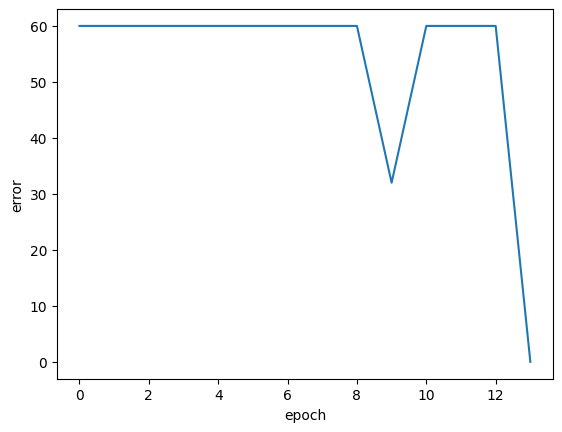

[np.int64(60), np.int64(60), np.int64(60), np.int64(60), np.int64(60), np.int64(60), np.int64(60), np.int64(60), np.int64(60), np.int64(32), np.int64(60), np.int64(60), np.int64(60), np.int64(0)]


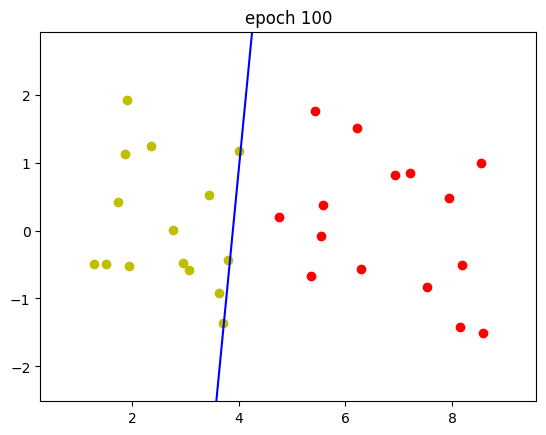

In [105]:
#Q1: part 2: Batch Preceptron
epoch=100
perceptron = Perceptron(X_train, Y_train, epochs=epoch,lr = 0.05)
w, err, converge_iter = perceptron.batch_fit(verbose=True)

#Visualize error
plt.plot(err)
plt.ylabel('error')
plt.xlabel('epoch')
plt.show()
print(err)

#Visualize training instances and boundary decision
bias=w[0]
a=w[1]
b=w[2]
perceptron.plot(a, b, bias, epoch)

In [106]:
# Q1: part 3: Batch Preceptron
y_pred_2 = []
X_test_batch = np.c_[np.ones(X_test.shape[0]), X_test]
for i in range(len(X_test_batch)):
 y_pred_2.append(perceptron.predict(X_test_batch[i]))
acc3 = accuracy_score(Y_test, y_pred_2)
print(acc3)

0.95


Error at epoch 0: 52
epochs 0: the weight:[[-2.        ]
 [ 1.49344468]
 [-0.99808371]] 



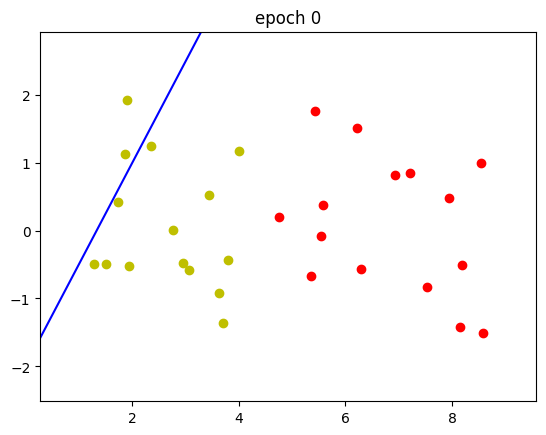

Error at epoch 1: 44
epochs 1: the weight:[[-4.        ]
 [ 2.33715068]
 [-2.16875705]] 



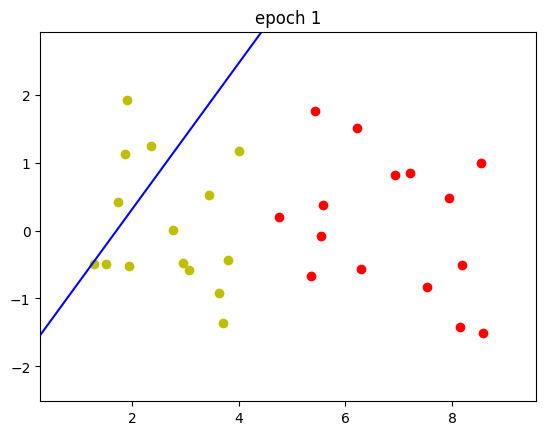

Error at epoch 2: 32
epochs 2: the weight:[[-6.        ]
 [ 2.18222415]
 [-2.25228684]] 



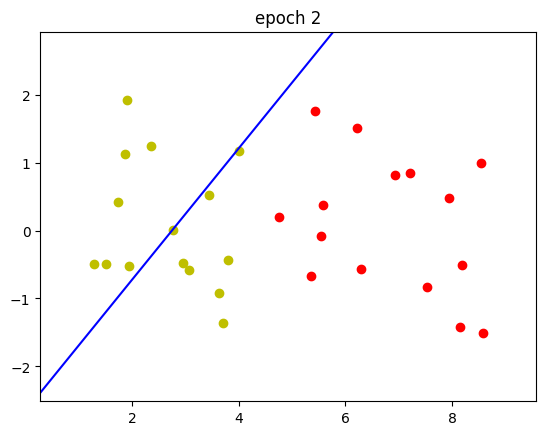

Error at epoch 3: 28
epochs 3: the weight:[[-7.5       ]
 [ 2.69747521]
 [-2.32381968]] 



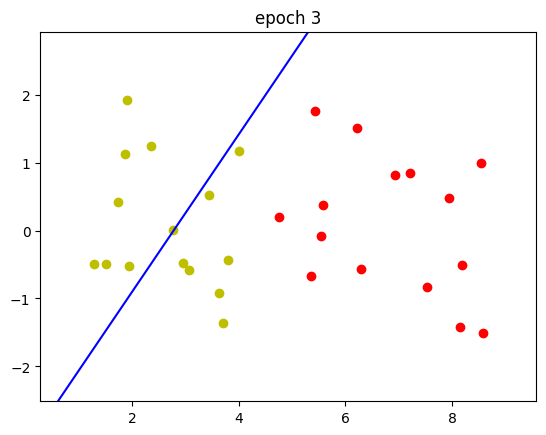

Error at epoch 4: 40
epochs 4: the weight:[[-8.        ]
 [ 4.61949414]
 [-2.38862019]] 



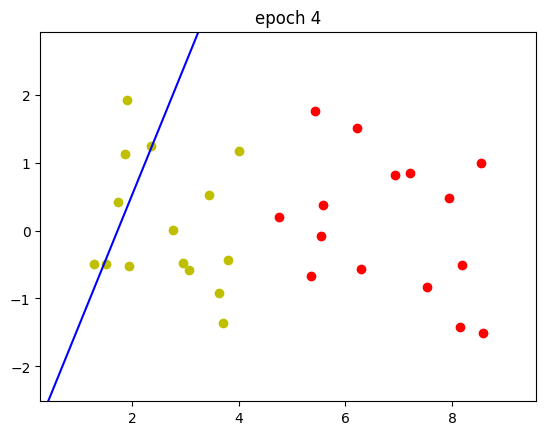

Error at epoch 5: 32
epochs 5: the weight:[[-9.        ]
 [ 3.91846766]
 [-0.68117887]] 



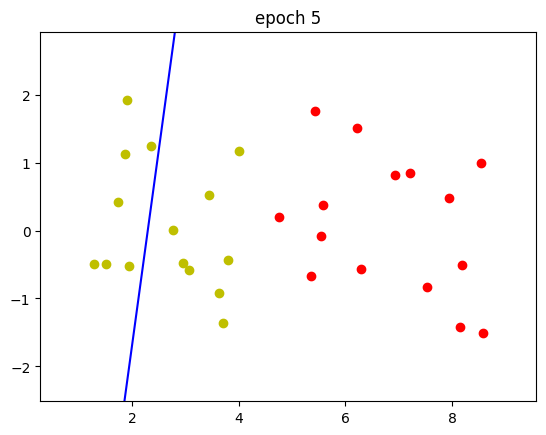

Error at epoch 6: 32
epochs 6: the weight:[[-10.       ]
 [  4.4511762]
 [ -0.7532463]] 



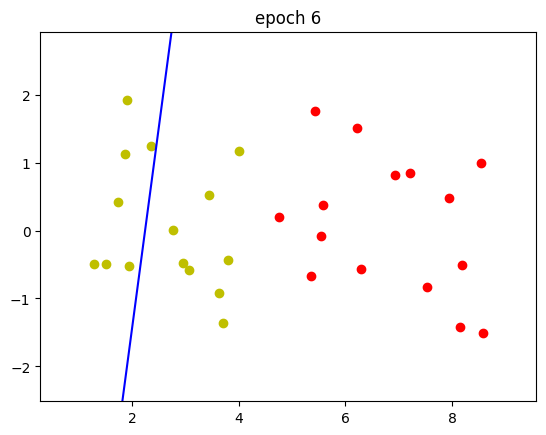

Error at epoch 7: 32
epochs 7: the weight:[[-11.        ]
 [  4.98388474]
 [ -0.82531372]] 



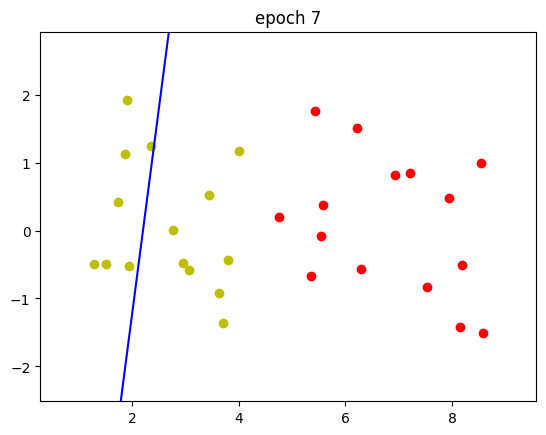

Error at epoch 8: 0
epochs 8: the weight:[[-12.        ]
 [  2.53475639]
 [ -0.22516508]] 



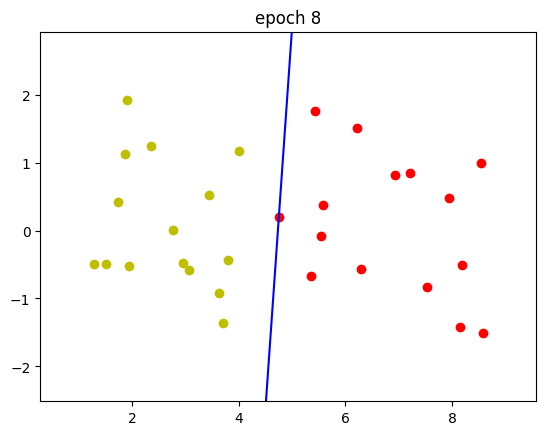

Last plot shows training data and resulting desicion boundary


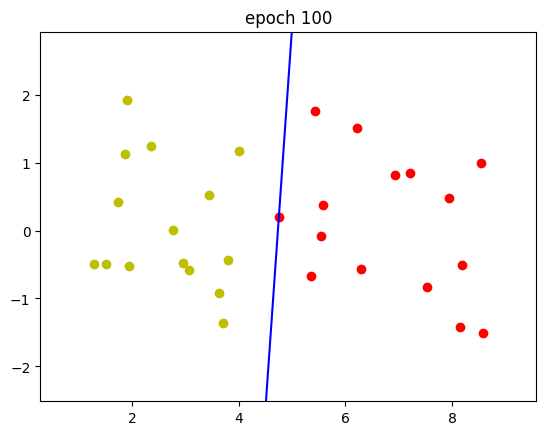

In [107]:
# Q1: part 4: Sequential Preceptron
perceptron_seq = Perceptron(X_train, Y_train, epochs=100,lr=0.5)
w, err_seq, converge_iter = perceptron_seq.seq_fit(verbose=True, plot=True) #Plot weights

#Plot training instances and decision boundary
bias=w[0]
a=w[1]
b=w[2]
#Last Plot shows training data and resulting desicion boundary
print('Last plot shows training data and resulting desicion boundary')
perceptron.plot(a, b, bias, epoch)

In [108]:
# Q1: part 5: Sequential Preceptron
y_pred_2 = []
X_test_seq = np.c_[np.ones(X_test.shape[0]), X_test]
for i in range(len(X_test_seq)):
 y_pred_2.append(perceptron_seq.predict(X_test_seq[i]))
acc3 = accuracy_score(Y_test, y_pred_2)
print(acc3)

1.0


In [109]:
#Q1: part 6
lr=[1e-5, 0.001, 0.01, 0.1, 1, 100]
#Batch Perceptron
conv_iter1=[] #store converge_iter
for i in lr:
  perceptron_batch = Perceptron(X_train, Y_train, epochs=100,lr=i)
  w_batch, err_batch, converge_iter_batch = perceptron_batch.batch_fit()
  conv_iter1.append(converge_iter_batch)
print(conv_iter1)

#Sequential Perceptron
conv_iter2=[] #store converge_iter
for j in lr:
  perceptron_seq = Perceptron(X_train, Y_train, epochs=100,lr=j)
  w_seq, err_seq, converge_iter_seq = perceptron_seq.seq_fit()
  conv_iter2.append(converge_iter_seq)
print(conv_iter2)

[15, 15, 15, 15, 15, 15]
[10, 10, 10, 10, 10, 10]


As I have seen from above code, changing learning rate did not change the iteration to convergence. I searched about it, and I found this in this website: https://datascience.stackexchange.com/a/36915
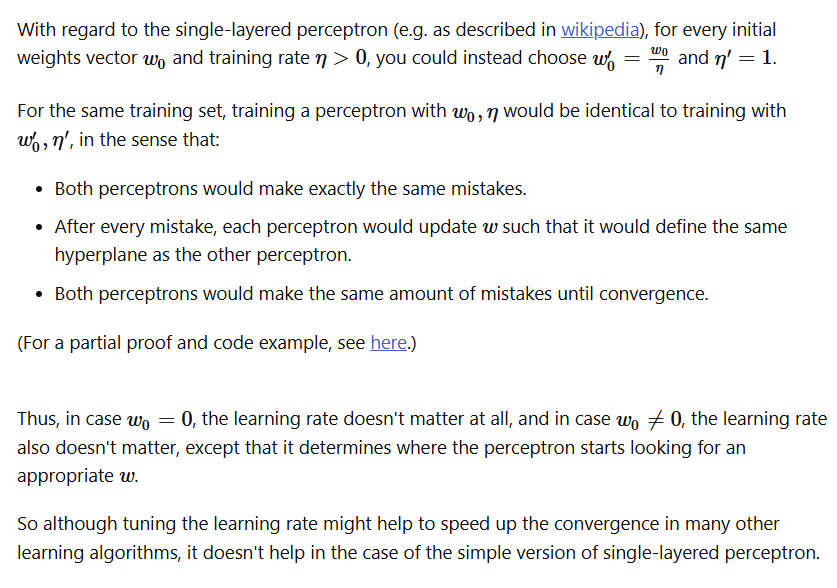

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn import datasets
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
%matplotlib inline

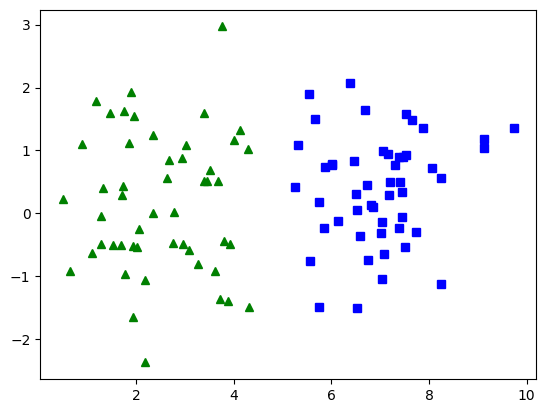

Classifier Weights:  [[3.08211022 0.56274991]]
Classifier Constant: [-14.]
1.0


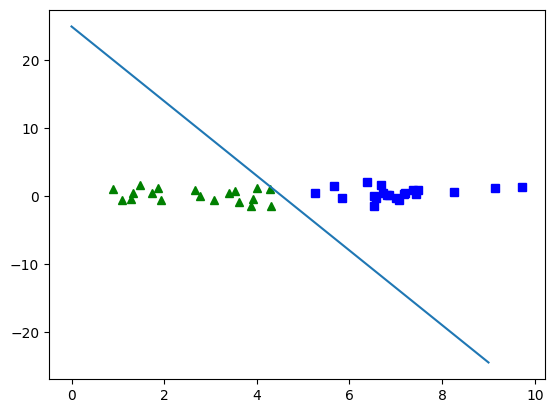

In [111]:
#Q2 Part A: Generating data and visualize it
n=100
X, y= datasets.make_blobs(n_samples=n, centers=2, n_features=2, center_box=(0, 10), cluster_std=1, random_state=41)
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'g^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
plt.show()

#Splitting dataset into training and test dataset
#y = y.reshape(n,1)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.4,random_state=420)

#Train the Pereceptron model to make prediction on the test
classifier=Perceptron()
classifier.fit(X_train, Y_train)
print("Classifier Weights: ", classifier.coef_)
print("Classifier Constant:", classifier.intercept_)

#Make prediction on test data
y_pred = classifier.predict(X_test)
accuracy_a=accuracy_score(Y_test, y_pred)
print(accuracy_a)

#Visualize the decision boundary of trained precepton model on top of the test data points
plt.plot(X_test[:, 0][Y_test == 0], X_test[:, 1][Y_test == 0], 'g^')
plt.plot(X_test[:, 0][Y_test == 1], X_test[:, 1][Y_test == 1], 'bs')
xx = np.linspace(0,9)
yy = (classifier.coef_[0][0]*xx + classifier.intercept_)/(-1*classifier.coef_[0][1])
plt.plot(xx, yy)
plt.show()

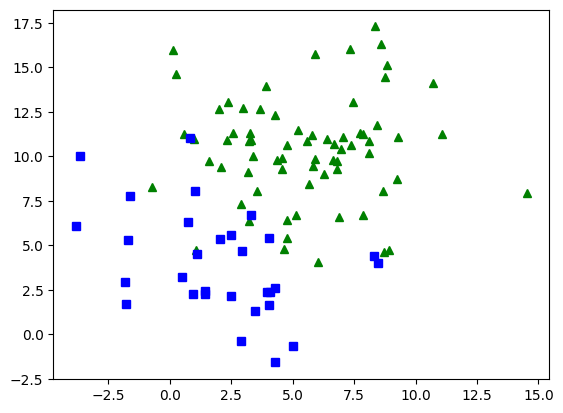

Classifier Weights:  [[-11.78857467 -15.0057968 ]]
Classifier Constant: [68.]
Accuracy: 0.8
precision: 1.0
recall: 0.42857142857142855
f1: 0.6
              precision    recall  f1-score   support

           0       0.76      1.00      0.87        26
           1       1.00      0.43      0.60        14

    accuracy                           0.80        40
   macro avg       0.88      0.71      0.73        40
weighted avg       0.85      0.80      0.77        40

[[26  0]
 [ 8  6]]


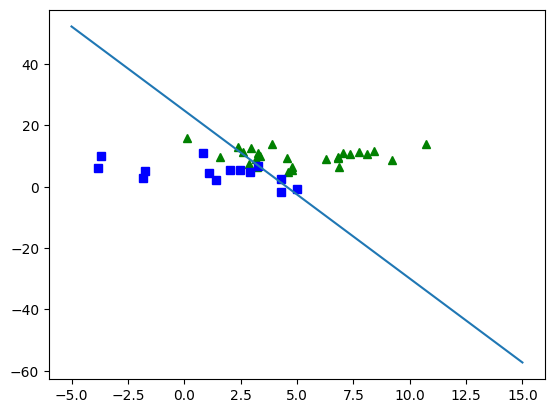

In [112]:
#Q2: Part B: Generating data that non linearly seperable and class imbalanced
n=[70,30]
centers=len(n)
X, y = datasets.make_blobs(n_samples=n, centers=None, n_features=2, center_box=(0, 10), cluster_std=3, random_state=1247)
y_shape = y.reshape(-1,1)
#Visualizing data
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'g^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
plt.show()

#Splitting data into training and test
X_train, X_test, Y_train, Y_test=train_test_split(X,y, test_size=0.4, random_state=240)

#Train the Pereceptron model to make prediction on the test
clf=Perceptron()
clf.fit(X_train, Y_train)
print("Classifier Weights: ", clf.coef_)
print("Classifier Constant:", clf.intercept_)

#Make prediction on test data
y_pred = clf.predict(X_test)

#show classification result
accuracy_b=accuracy_score(Y_test, y_pred)
print(f'Accuracy: {accuracy_b}')

precision_b=precision_score(Y_test, y_pred)
print(f'precision: {precision_b}')

recall_b=recall_score(Y_test, y_pred)
print(f'recall: {recall_b}')

f1_b=f1_score(Y_test, y_pred)
print(f'f1: {f1_b}')

classification_report_b=classification_report(Y_test, y_pred)
print(classification_report_b)

confusion_matrix_b=confusion_matrix(Y_test, y_pred)
print(confusion_matrix_b)

#Visualize the decision boundary
plt.plot(X_test[:, 0][Y_test == 0], X_test[:, 1][Y_test == 0], 'g^')
plt.plot(X_test[:, 0][Y_test == 1], X_test[:, 1][Y_test == 1], 'bs')
xx = np.linspace(-5,15)
yy = (classifier.coef_[0][0]*xx + classifier.intercept_)/(-1*classifier.coef_[0][1])
plt.plot(xx, yy)
plt.show()